<a href="https://colab.research.google.com/github/ratatatan/itmo-oomd/blob/lab1/%D0%9B%D0%B0%D0%B1%D0%BE%D1%80%D0%B0%D1%82%D0%BE%D1%80%D0%BD%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_1_%D0%A2%D0%BE%D0%BB%D0%BA%D0%B0%D1%87%D0%B5%D0%B2_%D0%9A3161.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Сделайте копию колаба (файл => создать копию на диске). Переименуйте, добавив в название ФИО и номер группы


## Задание 1.1

### Подготовка

Скачайте цветную картинку

In [1]:
# здесь нужно вписать свой URL!
! wget https://raw.githubusercontent.com/ratatatan/oomd/refs/heads/lab1/the_cat.jpg

--2025-02-27 15:37:56--  https://raw.githubusercontent.com/ratatatan/oomd/refs/heads/lab1/the_cat.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 211354 (206K) [image/jpeg]
Saving to: ‘the_cat.jpg’

the_cat.jpg         100%[===================>] 206.40K  --.-KB/s    in 0.03s   

2025-02-27 15:37:56 (6.00 MB/s) - ‘the_cat.jpg’ saved [211354/211354]



Эта картинка представляет собой матрицу с тремя каналами: R, G и B. Выведите картинку и её размеры.

In [2]:
from skimage.io import imread, imshow
import numpy as np
signal = np.ndarray
uint8 = np.uint8

<ipython-input-3-fb5132bec8e1>:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(image)


(1174, 1080, 3)


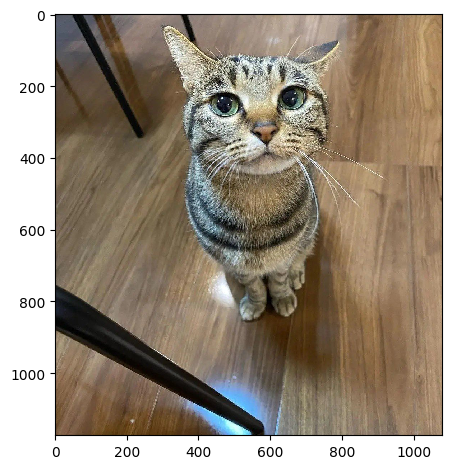

In [3]:
image = imread("./the_cat.jpg")
imshow(image)
print(image.shape)

Y = 0.299 ∗ R + 0.587 ∗ G + 0.114 ∗ B

Cb = −0.1687 ∗ R − 0.3313 ∗ G + 0.5 ∗ B + 128

Cr = 0.5 ∗ R − 0.4187 ∗ G − 0.0813 ∗ B + 128

Выше приведены формулы для перевода RGB в формат YCbCr. В этом формате Y представляет собой картинку в градациях серого (grayscale). (YUV - похожий формат)

Переведите картинку в формат YCbCr, используя формулы, описанные выше. Выведите каналы Y, Cb и Cr отдельно.

<ipython-input-4-e3cdcdf6e502>:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(Y)


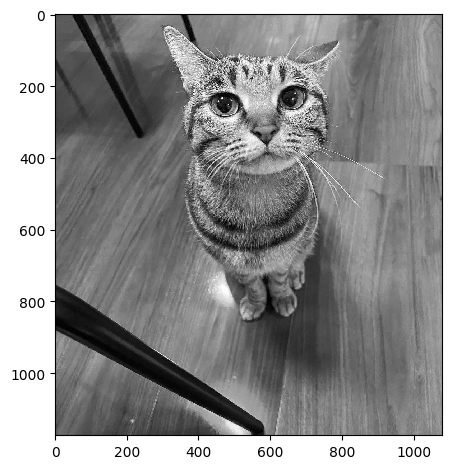

In [4]:
def rgb_to_ycbcr(R: signal, G: signal, B: signal) -> tuple[signal, signal, signal]:
  return uint8(0.299 * R + 0.587 * G + 0.114 * B), uint8(-0.1687 * R - 0.3313 * G + 0.5 * B + 128), uint8(0.5 * R - 0.4187 * G - 0.0813 * B + 128)

Y, Cb, Cr = rgb_to_ycbcr(image[:,:,0], image[:,:,1], image[:,:,2])

imshow(Y)

<ipython-input-5-399aed44d494>:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(Cb)


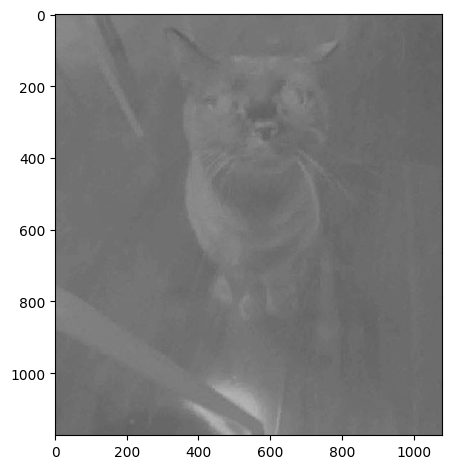

In [5]:
imshow(Cb)

<ipython-input-6-3f08fe0ed122>:1: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(Cr)


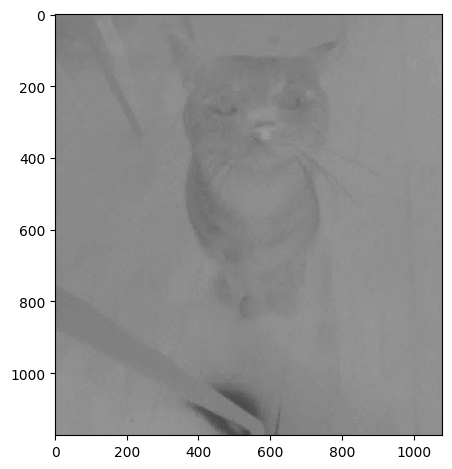

In [6]:
imshow(Cr)

В задании 1.1 нужно будет работать только с каналом Y. Предварительно сделайте его копию Y_copy, так как этот канал понадобится нам в задании 1.2 в неизменённом виде.

In [7]:
Y_copy = Y.copy()

### Теория

Дан сигнал $X$ предстваляющий собой последовательность значений $x_i$. Для X известно (или может быть легко вычислено) множество допустимых значений. Это множество допустимых значений может быть бесконечным, например, множество действительных чисел.

В задаче квантования элементам последовательности $X$ сопоставить элементы из множества $Y$. При этом множество $Y$ обязательно конечно и включает в себя меньшее чем в $X$ количество различных элементов.

Множество $Y$ называют *аппроксимирующим множеством*. Элементы из этого множества называют *аппроксимирующими значениями*.



0 до 10
(3, 4, 0, 3, 5, 6 .....) - входная последовательность

In [ ]:
0 - 0000

4 интервала

0 - [0 - 2.5], 1 - (2.5 - 5], 2 - (5 - 7.5], 3 - (7.5 - 10]

00 01 10 11

3 -> 1; 4 ->1; 0 -> 0; ... 6-> 2....

3, 4, 0, 3, 5, 6 ..... - входная последовательность

1, 1, 0, 1, 1, 2 ... - квантованная последовательность (последовательность из номеров квантов)

0 - 1.25; 1 - 3.75; 2 - 6.25 ... {1.25  3.75 6.25 } - аппроксимирующее множество

3.75, 3.75, 1.25, 3.75, 3.75, 6.25 ... - восстановленная последовательность

**Входная последовательность** - исходная последовательность элементов.

**Квантование** — это разбиение диапазона допустимых значений сигнала $X$ на конечное число уровней и это округление этих значений до ближайших к ним уровней, то есть сопоставлением каждому $x_i$ ближайших к ним аппроксимирующих значений.

**Равномерное квантование** — разбиение диапазона значений отсчётов на отрезки равной длины. Такие отрезки называют *квантами*. При этом обычно аппроксимирующие значения выбираются в центрах этих отрезков. При неравномерном квантовании отрезки могут быть разной длины, а аппроксимирующие значения могут находится не в центрах отрезков.



Обозначим через $Q$ множество номеров квантов. **Квантованная последовательность** - это последовательность номеров квантов, которые соответствуют элементам входной последовательности.

**Восстановленная последовательность** - это последовательность аппроксимирующих значений, соответствующих элементам входной последовательности.

**Скалярное квантование** — одному элементу из $X$ сопоставляется ровно одно аппроксимирующее значение. При векторном квантовании одно аппроксимирующее значение может быть сопоставлено сразу нескольким элементам из $X$.

В **равномерном квантовании с переменной скоростью** изначально задаётся ширина квантов (обычно её назвают шаг, step). В равномерном квантовании с постоянной скоростью задаётся количество бит, которые нужно потратить на один отчёт в квантованной последовательности. Вычислительно квантование с постоянной скоростью значительно сложнее, так как нужно находить границы квантов и определять, попадает ли элемент входной последовательность внутрь кванта.


Разберём на примере. Допустим у нас есть grayscale изображение. Яркость пикселей - это входная последовательность. Множество допустимых значений элементов входной последовательность: целые числа от 0 до 255. В результате квантования каждый элемент входной последовательности будет заменён ближайшим элементов их аппроксимирующего множества.

Получим сначала квантованную последовательность. Для этого нам необходимо задать ширину кванта $step$. В задаче с яркостью изображений ширина кванта задаётся степенью числа $2$. (Фактически в исходном изображении у нас шаг $1$, то есть $2^0$. Допустим, $step = 2^2 = 4$.

Обозначим через $y_q$ - элемент восстановленной последовательности. Тогда, $y_{q}=\left(\left\lfloor {x_i \over step}\right\rfloor +0.5\right)\cdot step$. При этом $\lfloor {x_i \over step} \rfloor$ - это номер соответствующего кванта.

Допустим в исходной последовательности встретились пиксели яркости 71, 73, 74. Тогда соответствующие им номера квантов будут равняться 17, 18, 18, а элементы восстановленной последовательности будут равнятся 70, 74, 74

In [ ]:
a = [71, 73, 74]

In [ ]:
import numpy as np

In [ ]:
b = np.array(a)

In [ ]:
a

[71, 73, 74]

In [ ]:
b

array([71, 73, 74])

In [ ]:
a // 4

TypeError: unsupported operand type(s) for //: 'list' and 'int'

In [ ]:
step = 4

In [ ]:
q = b // step

In [ ]:
q

array([17, 18, 18])

In [ ]:
y = (q + 0.5)*step

In [ ]:
b , y

(array([71, 73, 74]), array([70., 74., 74.]))

In [ ]:
(y - b)**2

array([1., 1., 0.])

In [ ]:
np.sum((y - b)**2) / len((y - b))

0.6666666666666666

### Формулировка задания

Напишите алгоритм **равномерного скалярного квантования с переменной скоростью**. Примените его к картинке Y_copy. Выведите получившуюся картинку. Вам потребуется подобрать значение $step$ такое, чтобы качество картинки оставалось приемлемым. Выведите первые 10 элементов входной последовательности, квантованной последовательности, восстановленной последовательности. Выведите все элементы аппроксимирующего множества.

#### Примечание

Не делайте в одной функции и получение квантованной последовательности и получение восстановленной последовательности. Это РАЗНЫЕ функции.

In [9]:
def quantize(img: signal, step: int) -> signal:
  img = img // step
  return img


def reconstruct_from_quantized(img: signal, step: int) -> signal:
  img = (img + 0.5) * step
  return img


step = 16
print("Входная последовательность: ", Y[:10, 0])
Y_copy = quantize(Y_copy, step)
approx_set = np.unique(Y_copy)
print("Квантованная последовательность: ", Y_copy[:10, 0])
Y_copy = reconstruct_from_quantized(Y_copy, step)
print("Восстановленная последовательность: ", Y_copy[:10, 0])
print("Все элементы аппроксимирующего множества: ", approx_set)

Входная последовательность:  [66 71 87 91 83 88 93 78 88 89]
Квантованная последовательность:  [4. 4. 5. 5. 5. 5. 5. 4. 5. 5.]
Восстановленная последовательность:  [72. 72. 88. 88. 88. 88. 88. 72. 88. 88.]
Все элементы аппроксимирующего множества:  [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15.]


# Задание 1.2

Ранее уже были приведены формулы для перевода из RGB и YCbCr. В этом задании нужно будет работать в основном с каналами Cb и Cr.

### Теория

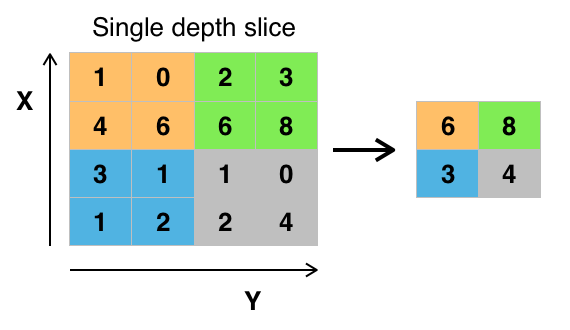

Выше приведена иллюстрация операции, которая называется pooling (точнее max pooling). Эта операция проводится на специальных слоях в свёрточной нейронной сети, предназначенной для анализа изображений. Суть операции сводится к следующему: в исходной матрице выбираются блоки заданного размера (в иллюстрации это блок 2 на 2), в каждом таком блоке выбирается элемент с максимальным значением. Этот максимальный элемент остаётся, а остальные отбрасываются.  

Альтернативой операции max pooling является операция average pooling (в этой операции выбирается не максимальный элемент, а счиается среднее арифметическое, иногда с округлением)

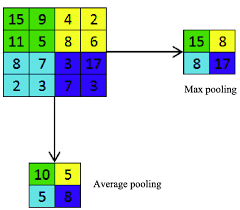

Похожая операция реализуется в стандарте JPEG. Эта часть называется [цветовая субдискретизация](https://ru.wikipedia.org/wiki/%D0%A6%D0%B2%D0%B5%D1%82%D0%BE%D0%B2%D0%B0%D1%8F_%D1%81%D1%83%D0%B1%D0%B4%D0%B8%D1%81%D0%BA%D1%80%D0%B5%D1%82%D0%B8%D0%B7%D0%B0%D1%86%D0%B8%D1%8F). Наиболее распространённый тип субдискретизации это 4:2:0.

Суть этого подхода к обработке изображений сводится к следующему. Каналы Cb и Cr называются цветоразностными. Для цветоразностных каналов делается децимация (прореживание, то есть отбрасывание элементов исходной матрицы). Для субдискретизации типа 4:2:0 нужно для в цветоразностных каналах для каждого блока 2 на 2 оставить только одно значение.

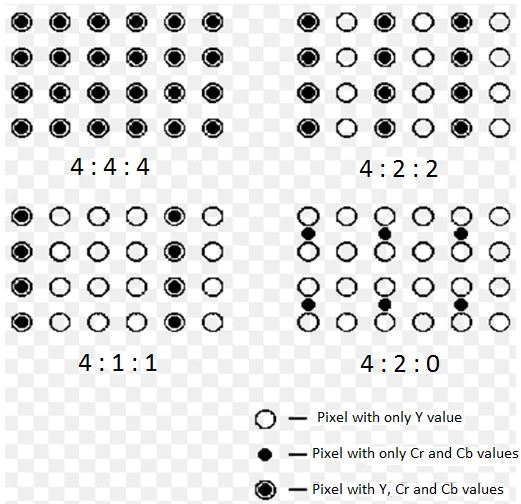

После цветовой субдискретиазации количество элементов в каналах Cb и Cr уменьшится. Для 4:2:0 количество элементов сократится в 4 раза. Чтобы снова перейти от формата YCbCr к RGB нужно восстановить цветоразностные каналы, а затем сделать пересчёт по формулам:

R = Y + 1.402 ∗ (Cr − 128)

G = Y − 0.34414 ∗ (Cb − 128) − 0.71414 ∗ (Cr − 128)

B = Y + 1.772 ∗ (Cb − 128)

## Формулировка задания

Для каналов Cb и Cr нужно сделать цветовую субдискретизацию типа 4:2:0. Нужно реализовать три типа обработки: прореживание (то есть обрасывание всех элементов кроме одного), среднее и максимальное.

В отдельной функции (методе) реализуйте восстановление цветоразностных каналов. В результате восстановления размеры этих матриц должны стать такими же как у матрицы Y.

После этого переведите изображение из YCbCr в формат RGB и выведите результат на экран. При переводе используйте каналы Cb, Cr, полученные после восстановления, иначе будет несовпадение по размерам.

Всего должно получится 6 картинок. Для неизменённого канала Y должно получиться три картинки для каждого типа обработки при цветовой субдискретизации. Также три картинки должны получится для канала Y после квантования в задании 1.1.

In [23]:
def ycbcr_to_rgb(Y: signal, Cb: signal, Cr: signal) -> tuple[signal, signal, signal]:
  return uint8(Y + 1.402 * (Cr - 128)), uint8(Y - 0.34414 * (Cb - 128) - 0.71414 * (Cr - 128)), uint8(Y + 1.772 * (Cb - 128))


def decimate_channel(channel: signal, side: int = 2) -> signal:
  return channel[::side, ::side]


def avg_pool_channel(channel: signal, side: int = 2) -> signal:
  l, w = channel.shape
  new_channel = np.zeros((l//side, w//side), dtype=np.uint8)
  for x in range(l//side):
    for y in range(w//side):
      new_channel[x, y] = np.average(channel[x*side:x*side+side, y*side:y*side+side])
  return new_channel


def max_pool_channel(channel: signal, side: int = 2) -> signal:
  l, w = channel.shape
  new_channel = np.zeros((l//side, w//side), dtype=np.uint8)
  for x in range(l//side):
    for y in range(w//side):
      new_channel[x, y] = np.max(channel[x*side:x*side+side, y*side:y*side+side])
  return new_channel


def reconstruct_from_subdiscretization(channel: signal, m: int = 2) -> signal:
  return np.repeat(np.repeat(channel, m, axis=0), m, axis=1)


def first(image: signal, Y_channel: signal, Cb_channel: signal, Cr_channel: signal, m: int = 2) -> signal:
  Cb_channel = reconstruct_from_subdiscretization(decimate_channel(Cb_channel))
  Cr_channel = reconstruct_from_subdiscretization(decimate_channel(Cr_channel))
  R, G, B = ycbcr_to_rgb(Y_channel, Cb_channel, Cr_channel)
  image[:, :, 0] = R
  image[:, :, 1] = G
  image[:, :, 2] = B
  return image

images = [

]




TypeError: ycbcr_to_rgb() missing 2 required positional arguments: 'Cb' and 'Cr'

# Задание 1.3

В этом задании нужно будет оценить качество сжатия данных. Оценивать будем каждую из шести картинок по двум параметрам: RMSE и степень сжатия (через энтропию).

## Теория

MSE и её модификация RMSE (корень квадратный из MSE) - метрики часто использующиеся в разных областях. В частности, их используют в статистики и машинном обучении для оценки качества регрессионной модели.

$$MSE =  \frac{1}{\ell} \sum\limits_{i=1}^\ell (\widehat y_{i}  - y_{i})^2 $$

Здесь $\ell$ количество пикселей в картинке (и в исходной и после обработки), $\widehat y_{i}$  и $y_{i}$ - яркости пикселей в исходной картинке и в картинке после обработки.

Степень сжатия рассчитывается по формуле:

$C = \frac{H_y}{H_{\widehat y}}$

$H_y$ - это среднее количество бит на один пиксель в исходном изображении. В этом задании это долно быть 24 бита.

$H_{\widehat y}$ - это оценка среднего количества бит на один пиксель в изображении после обработки.


Для оценки $H_{\widehat y}$ потребуется вычисление энтропию для последовательности элементов. Также это значение должно учитывать проведённую в задании 1.2 субдискретизацию. То есть **вы должны рассчитывать среднее количество бит не на восстановленном изображении, а на закодированном**. Помните о том, что в закодированном изображении количество элементов матрицы в два раза меньше.

Энтропия Шеннона для системы с N возможными состояниями определяется по формуле:
$$H = - \sum_{i=0}^{N} p_i\log_2p_i $$

где $p_i$ – вероятности нахождения системы в $i$-ом состоянии. Вероятность может быть оценена через частоту.

Это очень важное понятие теории информации, которое позволяет оценить количество информации (степень хаоса в системе). Чем выше энтропия, тем менее упорядочена система и наоборот. С помощью энтропии мы рассчитывем среднее количество бит на элемент последовательности, при условии что эту последовательность получится оптимально закодировать.

Энтропия важно понятие и для машинного обучения. Например, с её помощью формализуют функционал качества для разделение выборки при построении решающих деревьев, а кросс-энтропия используется как функционал качества при обучении (настройки параметров) разных моделей, в том числе нейронных сетей.

Приведём код для вычисления энтропии:

In [ ]:
import numpy as np

def entropy(x):

    _, counts = np.unique(x, return_counts=True)

    probabilities = counts / counts.sum()
    entropy = sum(probabilities * -np.log2(probabilities))

    return entropy

In [ ]:
s = [0, 1, 0, 1, 0, 1]
print (entropy(s))

1.0


In [ ]:
s = [0, 1, 2, 3, 0, 1, 3, 2]
print (entropy(s))

2.0


In [ ]:
s = [0, 0, 0, 0, 0, 1]
print (entropy(s))

0.6500224216483541


In [ ]:
s = [0, 0, 2, 2, 0, 0, 2, 2]
print (entropy(s))

1.0


## Формулировка задания

Для изображения в формате grayscale в задании 1.1 рассчитайте степень сжатия и RMSE.

Для каждой их 6 картинок вычислите RMSE и степень сжатия. Выведите результат в удобочитаемом формате.



In [ ]:
# YOUR CODE HERE

Картинка сжималась путём снижения яркостного разрешения (в задании 1.1) и путём цветовой субдисрктизации (задание 1.2).. Какой из этих методов дал наибольший вклад в сжатие данных? Какой их этих методов внёс наибольшую ошибку?
Какой тип типа обработки при цветовой субдискретизации оказался наиболее эффективным?

Ответы напишите ниже.